In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-churn-dataset/Churn_Modelling.csv


***Import dataset***

In [2]:
df=pd.read_csv('/kaggle/input/customer-churn-dataset/Churn_Modelling.csv')

***Showing head dataset***

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


***Check shape od data***

In [4]:
df.shape

(10000, 14)

***Basic information of dataset***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


***Check null value in data***

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

***Check duplicate data***

In [7]:
df.duplicated().sum()

0

***Drop unwanted columns***

In [8]:
df.drop(columns='RowNumber',inplace =True)

***Value count of country***

In [9]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

***Import visualization library***

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

***ploting of geography***

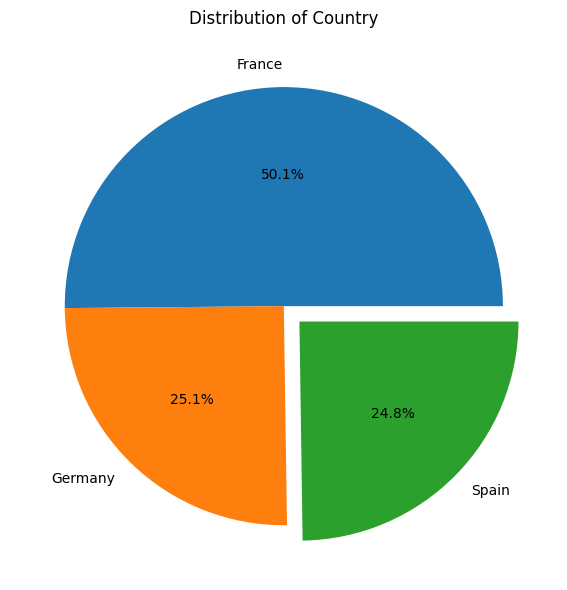

In [11]:
plt.figure(figsize=(6,6))
plt.pie(df['Geography'].value_counts(),labels=['France','Germany','Spain'],autopct='%1.1f%%',explode=[0,0,0.1])
plt.title('Distribution of Country')
plt.tight_layout()
plt.show()

In [12]:
gender=df['Gender'].value_counts().reset_index()
gender

,Gender,count
0,Male,5457
1,Female,4543


***Weightage of gender***

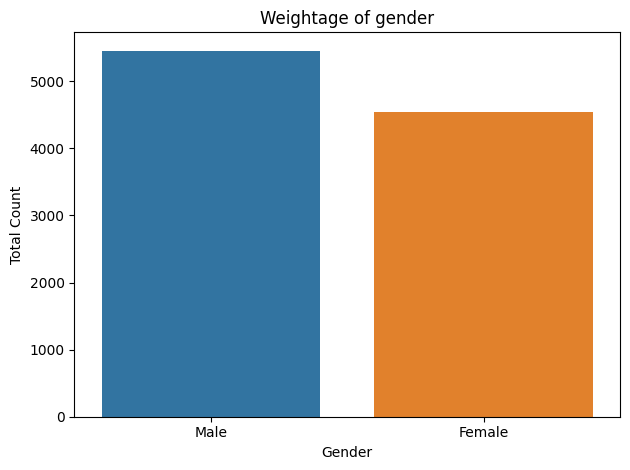

In [13]:
sns.barplot(data=gender,x='Gender',y='count')
plt.title('Weightage of gender')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

In [14]:
numofproduct = df.groupby('Gender')['NumOfProducts'].sum().reset_index()
numofproduct

,Gender,NumOfProducts
0,Female,7015
1,Male,8287


***Scatterplot of Age vs Salary based on  gender***

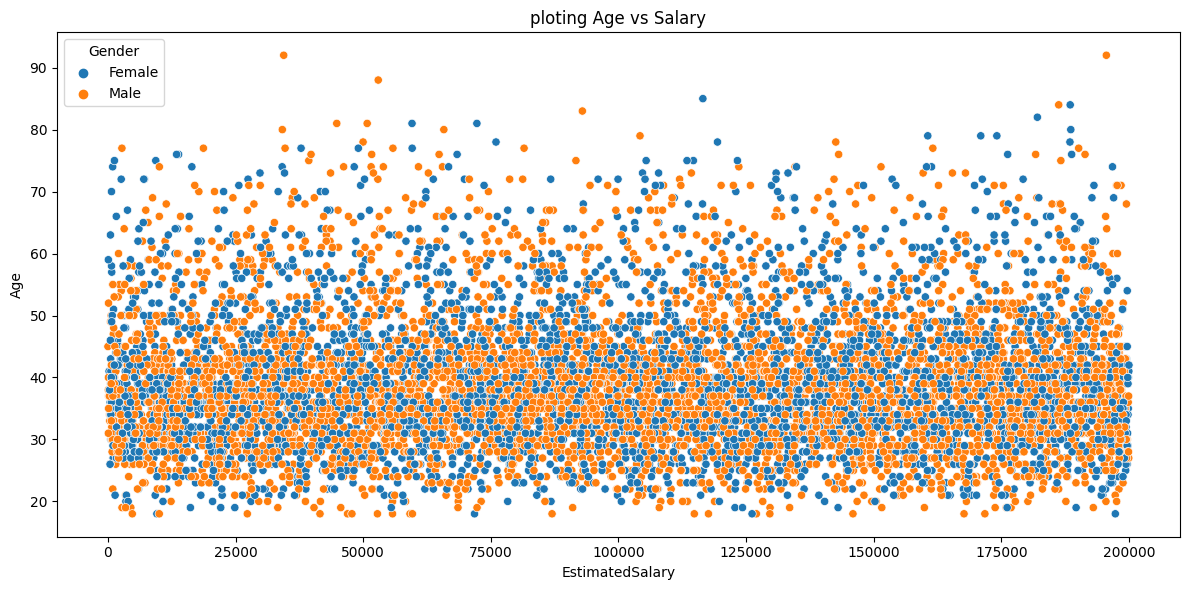

In [15]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,y='Age',x='EstimatedSalary',hue='Gender')
plt.title('ploting Age vs Salary')
plt.tight_layout()
plt.show()

***Scatter plot creditscore vs salary based on gender***

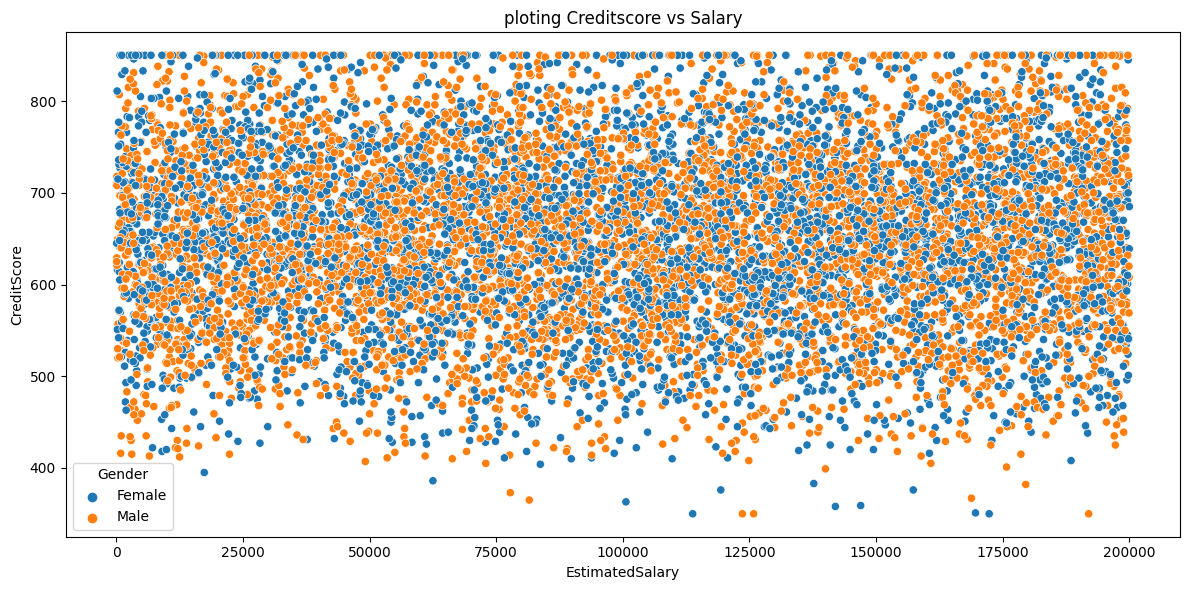

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,y='CreditScore',x='EstimatedSalary',hue='Gender')
plt.title('ploting Creditscore vs Salary')
plt.tight_layout()
plt.show()

***The number of years the customer has been with the bank***

In [17]:
Tenure=df['Tenure'].value_counts().reset_index()
Tenure

,Tenure,count
0,2,1048
1,1,1035
2,7,1028
3,8,1025
4,5,1012
5,3,1009
6,4,989
7,9,984
8,6,967
9,10,490


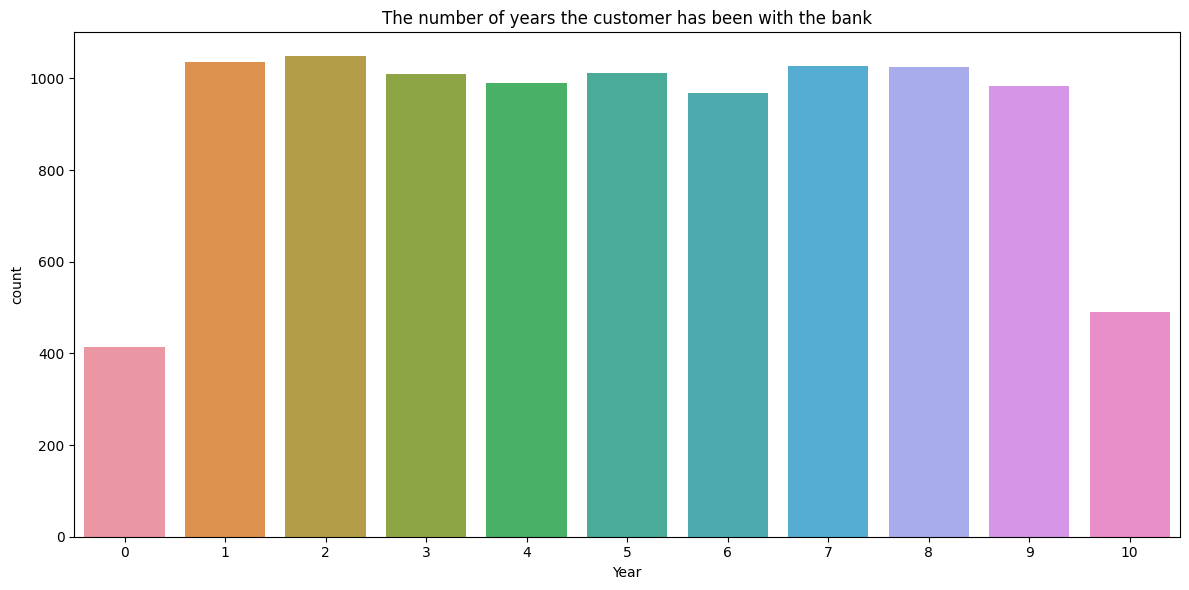

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(data=Tenure,x='Tenure',y='count')
plt.title('The number of years the customer has been with the bank')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

In [19]:
df.groupby('Geography')['Gender'].size()

Geography
France     5014
Germany    2509
Spain      2477
Name: Gender, dtype: int64

In [20]:
cross_tab = pd.crosstab(df['Geography'], df['Gender'])

# Print the cross-tabulation
cross_tab

Gender,Female,Male
Geography,,
France,2261,2753
Germany,1193,1316
Spain,1089,1388


***Find min,max,std,mean,count***

In [21]:
df1=df.drop(columns='CustomerId')
df1.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.000000,650.528800,96.653299,350.000000,584.000000,652.000000,718.000000,850.000000
Age,10000.000000,38.921800,10.487806,18.000000,32.000000,37.000000,44.000000,92.000000
Tenure,10000.000000,5.012800,2.892174,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,10000.000000,76485.889288,62397.405202,0.000000,0.000000,97198.540000,127644.240000,250898.090000
NumOfProducts,10000.000000,1.530200,0.581654,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,10000.000000,0.705500,0.455840,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,10000.000000,0.515100,0.499797,0.000000,0.000000,1.000000,1.000000,1.000000
EstimatedSalary,10000.000000,100090.239881,57510.492818,11.580000,51002.110000,100193.915000,149388.247500,199992.480000
Exited,10000.000000,0.203700,0.402769,0.000000,0.000000,0.000000,0.000000,1.000000


In [22]:
df.sample(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8461,15758769,Coffey,625,France,Female,44,7,0.00,1,1,0,4791.80,0
7267,15724851,Farmer,507,Germany,Male,31,9,111589.67,1,1,0,150037.19,0
3561,15614302,Crotty,699,Germany,Female,31,10,125837.86,2,1,0,189392.66,0
1328,15574331,Alexeeva,593,Germany,Female,62,3,118233.81,1,0,1,24765.53,1
3370,15749905,Carr,698,Spain,Female,47,6,0.00,1,1,0,50213.81,1


In [23]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

***Active Member by ploting Yes/No***

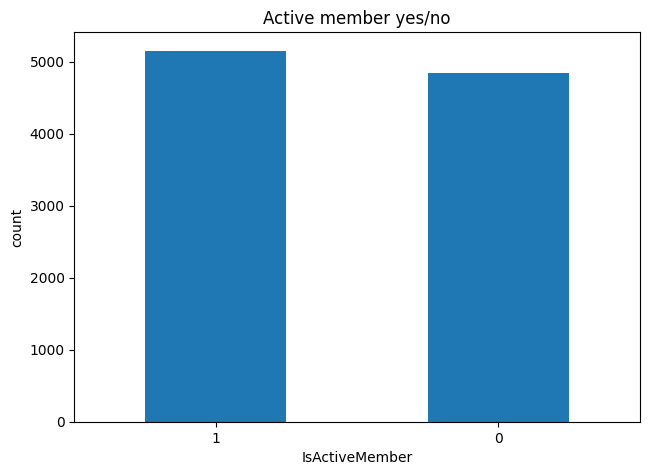

In [24]:
df['IsActiveMember'].value_counts().plot(kind='bar')
plt.title('Active member yes/no')
plt.tight_layout()
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()